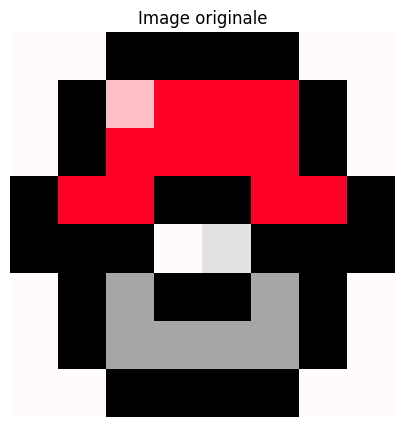

Palette (RGB) :
 [[253 246 247]
 [  0   0   0]
 [255   0  39]
 [166 166 166]]
Inertia (erreur intra-cluster) : 7470.421052631578
Nombre d'itérations : 2


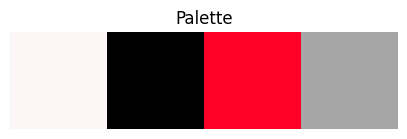

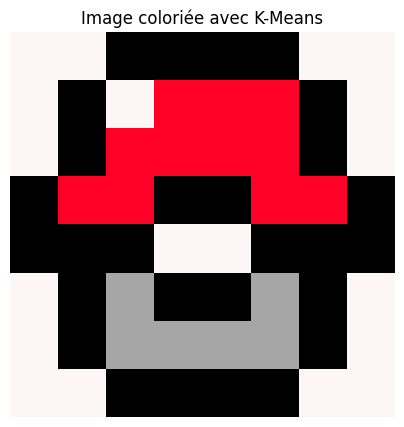

or 106.33333333333333
re 106.22916666666667


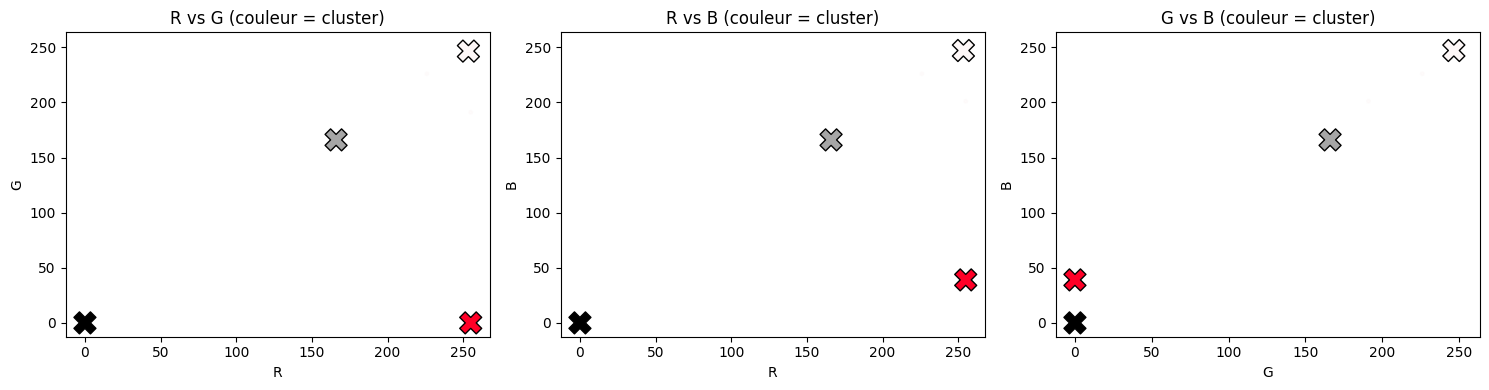

In [3]:
# palette de couleurs avec K-Means (scikit-learn)

# 1) Imports
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans


# 2) Charger une image (RGB) -> ndarray uint8 (H, W, 3)
def load_image(path: str) -> np.ndarray:
    """
    Ouvre une image, force le format RGB, et renvoie un ndarray (uint8).
    - H = hauteur (lignes)
    - W = largeur (colonnes)
    - 3 = canaux RGB
    """
    image_pil = Image.open(path).convert("RGB")
    image_array = np.array(image_pil, dtype=np.uint8)
    return image_array


# 3) Afficher une image
def show_image(image_array: np.ndarray, title: str = ""):
    """
    Affiche un ndarray image (H, W, 3) avec matplotlib.
    """
    plt.figure(figsize=(5, 5))
    plt.imshow(image_array)
    plt.title(title)
    plt.axis("off")
    plt.show()


# 4) Transformer l'image en "dataset" de pixels : (n_pixels, 3)
def image_to_pixel_dataset(image_array: np.ndarray) -> np.ndarray:
    """
    Convertit une image (H, W, 3) en une liste de pixels (n_pixels, 3).
    Chaque ligne = un pixel = [R, G, B].
    On convertit en float pour KMeans.
    """
    pixels = image_array.reshape(-1, 3).astype(float)  # (H*W, 3)
    return pixels


# 5) Afficher une palette de couleurs (K couleurs)
def show_palette(palette_rgb: np.ndarray, title: str = "Palette"):
    """
    Affiche la palette sous forme de bandes de couleurs.
    palette_rgb : ndarray (K, 3) en uint8
    """
    
    palette_image = palette_rgb.reshape(1, -1, 3)          # (1, K, 3)

    show_image(palette_image, title="Palette")

# 6) Extraire une palette de K couleurs avec KMeans
def extract_palette_kmeans(pixels: np.ndarray, number_of_colors: int, random_state: int = 0):
    """
    Applique KMeans sur des pixels (n_pixels, 3) pour trouver K couleurs "dominantes".
    
    Retour :
    - kmeans_model : le modèle entraîné
    - palette_rgb  : ndarray (K, 3) en uint8 (les centroïdes)
    """
    kmeans_model = KMeans(
        n_clusters=number_of_colors,
        init="k-means++",
        n_init="auto",        # recommandé / valeur moderne par défaut
        random_state=random_state
    )

    # On entraîne KMeans sur les pixels
    kmeans_model.fit(pixels)

    # Les centres sont des floats (moyennes). On les convertit en couleurs RGB uint8.
    palette_float = kmeans_model.cluster_centers_               # (K, 3) float
    palette_clipped = np.clip(palette_float, 0, 255)            # sécurité
    palette_rgb = palette_clipped.astype(np.uint8)              # (K, 3) uint8

    return kmeans_model, palette_rgb


# 7) Recolorer l'image avec la palette (quantification)
def recolor_image_with_palette(image_array: np.ndarray, kmeans_model, palette_rgb: np.ndarray) -> np.ndarray:
    """
    Pour chaque pixel de l'image, on trouve le cluster le plus proche,
    puis on remplace le pixel par la couleur du centroïde correspondant.
    
    Résultat : une image "réduite" à K couleurs.
    """
    height, width, _ = image_array.shape

    # 1) Image -> pixels (n_pixels, 3)
    pixels = image_to_pixel_dataset(image_array)

    # 2) Pour chaque pixel, prédire le cluster (0..K-1)
    pixel_labels = kmeans_model.predict(pixels)  # (n_pixels,)

    # 3) Remplacer chaque pixel par la couleur palette_rgb[label]
    recolored_pixels = palette_rgb[pixel_labels]  # (n_pixels, 3)

    # 4) Remettre en forme image (H, W, 3)
    recolored_image = recolored_pixels.reshape(height, width, 3)

    return recolored_image

def plot_pixels_rgb_3d(pixels, labels, centroids, max_points=3000):
    # Échantillonnage pour éviter 200 000 points
    if pixels.shape[0] > max_points:
        idx = np.random.choice(pixels.shape[0], max_points, replace=False)
        P = pixels[idx]
        L = labels[idx]
    else:
        P, L = pixels, labels

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(P[:, 0], P[:, 1], P[:, 2], s=5)  # nuage de pixels
    ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
               marker="X", s=250)               # centroïdes

    ax.set_xlabel("R")
    ax.set_ylabel("G")
    ax.set_zlabel("B")
    ax.set_title("Pixels (RGB) + centroïdes KMeans")
    plt.show()

def plot_pixels_rgb_2d_projections_colored(pixels, labels, centroids, max_points=5000):
    """
    pixels    : (n,3) float ou uint8
    labels    : (n,) int (0..K-1)
    centroids : (K,3) float (souvent), valeurs 0..255
    """

    # 1) Échantillonnage pour éviter trop de points
    n = pixels.shape[0]
    if n > max_points:
        idx = np.random.choice(n, max_points, replace=False)
        P = pixels[idx]
        L = labels[idx]
    else:
        P = pixels
        L = labels

    # 2) Convertir les centroïdes en couleurs "matplotlib" (0..1)
    centroid_colors = np.clip(centroids, 0, 255) / 255.0   # (K,3) float 0..1

    # 3) Chaque point prend la couleur de son cluster
    point_colors = centroid_colors[L]                      # (n_sample,3)

    pairs = [
        (0, 1, "R", "G"),
        (0, 2, "R", "B"),
        (1, 2, "G", "B")
    ]

    plt.figure(figsize=(15, 4))

    for i, (a, b, xa, yb) in enumerate(pairs, start=1):
        plt.subplot(1, 3, i)

        # Nuage de points coloré par cluster (couleur du centroïde)
        plt.scatter(P[:, a], P[:, b], s=6, c=point_colors, alpha=0.4)

        # Centroïdes : gros X, colorés eux-mêmes
        plt.scatter(centroids[:, a], centroids[:, b],
                    marker="X", s=250, c=centroid_colors, edgecolors="black", linewidths=1)

        plt.xlabel(xa)
        plt.ylabel(yb)
        plt.title(f"{xa} vs {yb} (couleur = cluster)")

    plt.tight_layout()
    plt.show()

# -------------------------
# EXECUTION
# -------------------------

# A) Charger et afficher l'image
# original_image = load_image("red_blue_uneven.png")
original_image = load_image("pokeball.png")
show_image(original_image, title="Image originale")

# B) Choisir K = nombre de couleurs dans la palette
K = 4 # essaye 4, 6, 8, 12...

# C) Convertir l'image en dataset de pixels
pixel_dataset = image_to_pixel_dataset(original_image)

training_pixels = pixel_dataset

# D) KMeans -> palette
kmeans_model, palette_rgb = extract_palette_kmeans(training_pixels, number_of_colors=K, random_state=0)

print("Palette (RGB) :\n", palette_rgb)
print("Inertia (erreur intra-cluster) :", kmeans_model.inertia_)
print("Nombre d'itérations :", kmeans_model.n_iter_)

show_palette(palette_rgb, title=f"Palette K={K} (K-Means)")

# E) Recolorer l'image avec cette palette
recolored_image = recolor_image_with_palette(original_image, kmeans_model, palette_rgb)

# F) Afficher avant / après
show_image(recolored_image, "Image coloriée avec K-Means")
print("or", original_image.mean())
print("re", recolored_image.mean())

pixels = image_to_pixel_dataset(original_image)     # (n,3) float
kmeans_model.fit(pixels)

labels = kmeans_model.labels_                       # (n,)
centroids = kmeans_model.cluster_centers_           # (K,3)

plot_pixels_rgb_2d_projections_colored(pixels, labels, centroids, max_points=8000)
